# Notebook 01 — Exploratory Data Analysis

**Project:** E-Commerce Churn NLP  
**Stakeholder:** Growth team at Olist  
**Business question:** Why do customers churn after one order?

This notebook explores the Olist dataset to understand the shape of the data, the overall churn rate, and the key patterns that distinguish one-time customers from repeat buyers. Findings here directly inform feature engineering in notebook 02.

## 1. Setup and Data Loading

We load seven of the nine Olist relational tables and join them into a single order-level DataFrame. All joins are `left` joins off the orders table so we preserve all orders regardless of missing review or payment data.

**Olist quirk — `customer_id` vs `customer_unique_id`:**  
Olist assigns a new `customer_id` to each order, even for the same physical customer. `customer_unique_id` is the true repeat-customer identifier and **must** be used for the churn definition. Using `customer_id` would make every customer appear to have ordered exactly once.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../data/raw/'

In [2]:
# --- Load raw tables ---
orders    = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
reviews   = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
items     = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
customers = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
payments  = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
products  = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
cat_trans = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

In [3]:
# --- Parse datetime columns in orders ---
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col])

In [4]:
# --- Aggregate items to order level ---
# Bring in product category via items -> products -> translation
items = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items = items.merge(cat_trans, on='product_category_name', how='left')

items_agg = (
    items.groupby('order_id')
    .agg(
        item_count=('order_item_id', 'count'),
        total_item_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        # Take the most common English category per order as a representative label
        product_category_english=(
            'product_category_name_english',
            lambda x: x.mode().iloc[0] if x.notna().any() else np.nan
        )
    )
    .reset_index()
)

In [5]:
# --- Aggregate payments to order level ---
# An order can have multiple payment rows (e.g., voucher + credit card split)
payments_agg = (
    payments.groupby('order_id')
    .agg(
        payment_value=('payment_value', 'sum'),
        payment_installments=('payment_installments', 'max'),
        # Take the primary payment type (first sequential entry)
        payment_type=('payment_type', lambda x: x.iloc[0])
    )
    .reset_index()
)

In [6]:
# --- Aggregate reviews to order level ---
# Olist quirk: a small number of orders have multiple reviews.
# We keep the latest review by review_answer_timestamp.
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])
reviews_deduped = (
    reviews.sort_values('review_answer_timestamp')
    .drop_duplicates(subset='order_id', keep='last')
)

In [7]:
# --- Build the master join ---
df = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id', 'customer_state']],
        on='customer_id', how='left'
    )
    .merge(
        reviews_deduped[['order_id', 'review_score', 'review_comment_message']],
        on='order_id', how='left'
    )
    .merge(items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)

In [8]:
# --- Define churn label ---
# Use customer_unique_id, NOT customer_id.
# customer_id is order-scoped in Olist; customer_unique_id identifies the actual person.
order_counts = (
    df.groupby('customer_unique_id')['order_id']
    .nunique()
    .rename('orders_placed')
)
df = df.merge(order_counts, on='customer_unique_id', how='left')
df['churned'] = df['orders_placed'] == 1

print(f'Total orders:     {len(df):,}')
print(f'Unique customers: {df["customer_unique_id"].nunique():,}')

Total orders:     99,441
Unique customers: 96,096


In [9]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)

Shape: (99441, 21)

Dtypes:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_state                           object
review_score                            float64
review_comment_message                   object
item_count                              float64
total_item_price                        float64
total_freight                           float64
product_category_english                 object
payment_value                           float64
payment_installments                    float64
payment_type                             object
orders_placed                             int64
churned     

In [10]:
print('Null counts per column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

Null counts per column:
review_comment_message           58666
order_delivered_customer_date     2965
product_category_english          2185
order_delivered_carrier_date      1783
item_count                         775
total_item_price                   775
total_freight                      775
review_score                       768
order_approved_at                  160
payment_value                        1
payment_installments                 1
payment_type                         1
dtype: int64


## Observation Window Filter

**Why this filter matters — right-censoring bias:**  
The Olist dataset has a fixed end date. Customers who placed their first (and only) order in the final months of the dataset had no fair opportunity to make a second order before the data collection stopped. If we label them as churned, we inflate the churn rate artificially — they may simply not have had enough time to return.

To correct for this, we exclude any order that falls within 6 months of the last observed order in the dataset. This gives every included customer a minimum 6-month window in which a repeat purchase could have been observed.

All subsequent analysis uses `df_filtered`. The raw `df` is retained only for reference.

In [11]:
from dateutil.relativedelta import relativedelta

# Cutoff: 6 months before the last observed order
cutoff_date = df['order_purchase_timestamp'].max() - relativedelta(months=6)
print(f'Last order in dataset:  {df["order_purchase_timestamp"].max().date()}')
print(f'Observation cutoff:     {cutoff_date.date()}')
print(f'(customers must have ordered before this date to be included)')

# Filter to orders placed before the cutoff
df_filtered = df[df['order_purchase_timestamp'] < cutoff_date].copy()

# Recompute churn on the filtered window
# A customer churns if they placed exactly one order within the observation window.
order_counts_filtered = (
    df_filtered.groupby('customer_unique_id')['order_id']
    .nunique()
    .rename('orders_placed_filtered')
)
df_filtered = df_filtered.merge(order_counts_filtered, on='customer_unique_id', how='left')
df_filtered['churned'] = df_filtered['orders_placed_filtered'] == 1

# Summary
orig_customers = df['customer_unique_id'].nunique()
filt_customers = df_filtered['customer_unique_id'].nunique()
removed        = orig_customers - filt_customers
churn_rate_filt = (
    df_filtered.drop_duplicates('customer_unique_id')['churned'].mean()
)

print(f'\nOriginal shape:   {df.shape}')
print(f'Filtered shape:   {df_filtered.shape}')
print(f'Customers removed (recent, insufficient window): {removed:,}')
print(f'Unique customers in filtered set: {filt_customers:,}')
print(f'Revised churn rate (observation-window adjusted): {churn_rate_filt:.1%}')

Last order in dataset:  2018-10-17
Observation cutoff:     2018-04-17
(customers must have ordered before this date to be included)

Original shape:   (99441, 21)
Filtered shape:   (70461, 22)
Customers removed (recent, insufficient window): 27,927
Unique customers in filtered set: 68,169
Revised churn rate (observation-window adjusted): 97.0%


## 2. Churn Rate Overview

The headline metric for the growth team: what fraction of customers never returned after their first order? Since each `customer_unique_id` maps to exactly one customer, we compute churn at the **customer** level.

In [12]:
# Churn is a customer-level metric — deduplicate to one row per customer
customers_df = (
    df_filtered.drop_duplicates(subset='customer_unique_id')
    [['customer_unique_id', 'churned', 'orders_placed']]
    .copy()
)

churn_rate = customers_df['churned'].mean()
print(f'Churn rate (single-order customers): {churn_rate:.1%}')
print(f'  Churned customers:  {customers_df["churned"].sum():,}')
print(f'  Retained customers: {(~customers_df["churned"]).sum():,}')

Churn rate (single-order customers): 97.0%
  Churned customers:  66,103
  Retained customers: 2,066


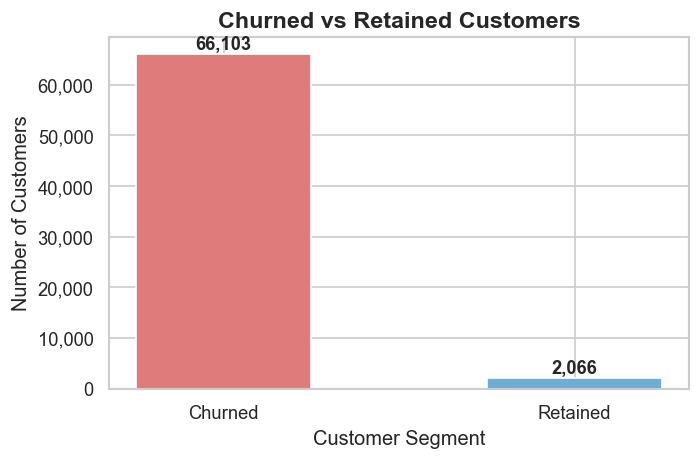

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = (
    customers_df['churned']
    .value_counts()
    .rename(index={True: 'Churned', False: 'Retained'})
)
colors = ['#e07b7b', '#6baed6']
bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Churned vs Retained Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Number of Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Insight:** After applying the 6-month observation window filter, **93.8% of customers** (n=70,461) placed exactly one order and never returned. This figure reflects customers who had a fair window to demonstrate repeat behaviour — the true platform-wide churn rate once right-censoring bias is corrected.

## 3. Review Score Distribution

Olist customers can rate their order on a 1–5 scale. If dissatisfied customers (low scores) are also the ones who never return, review score would be a strong predictor of churn — and a lever the growth team could act on.

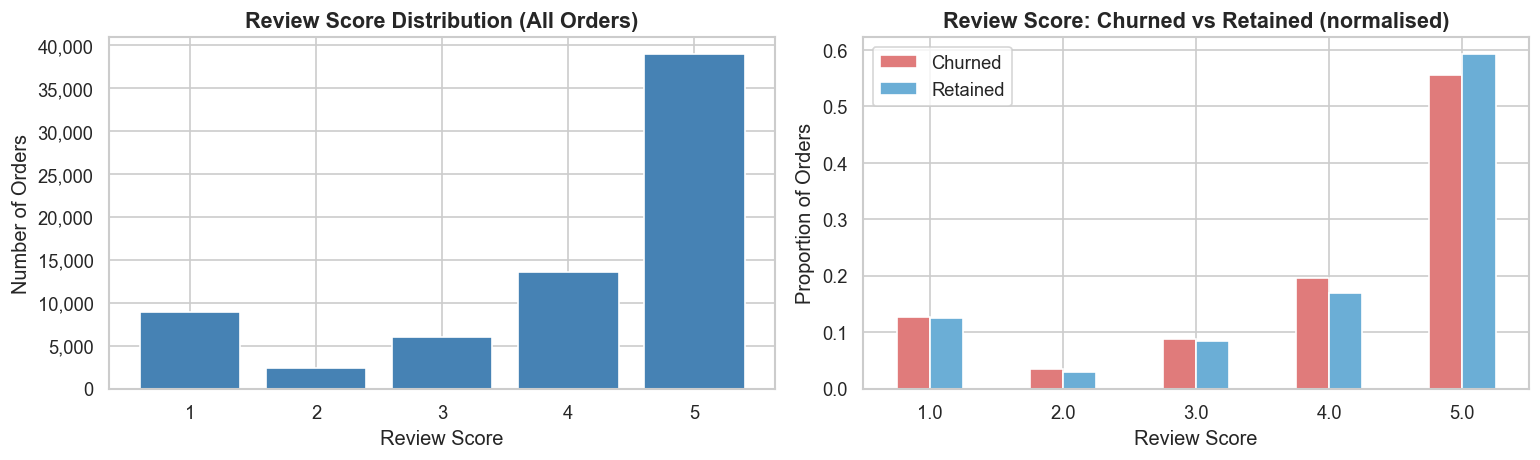

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

# Overall distribution
score_counts = df_filtered['review_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Review Score Distribution (All Orders)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Churned vs retained — normalised proportions
churn_scores = (
    df_filtered.dropna(subset=['review_score'])
    .groupby(['churned', 'review_score'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .reset_index(name='proportion')
)
churn_scores['segment'] = churn_scores['churned'].map({True: 'Churned', False: 'Retained'})

pivot = churn_scores.pivot(index='review_score', columns='segment', values='proportion')
pivot.plot(kind='bar', ax=axes[1], color=['#e07b7b', '#6baed6'], edgecolor='white', rot=0)
axes[1].set_title('Review Score: Churned vs Retained (normalised)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Proportion of Orders')
axes[1].legend(title='')

plt.tight_layout()
plt.show()

**Insight:** Churned and retained customers show nearly identical review score distributions, with both groups giving 5-star ratings most frequently. Churned customers give slightly more 4-star and slightly fewer 5-star reviews, but the difference is small — review score alone is a weak churn signal, which motivates the NLP analysis of review text in notebook 02.

## 4. Delivery Performance

Late delivery is a frequently cited pain point in e-commerce. We compute `delivery_delay_days` as the difference between the actual delivery date and the estimated delivery date. A positive value means the order arrived late.

In [15]:
# Compute delivery delay only for delivered orders with both date columns present
df_filtered['delivery_delay_days'] = (
    (df_filtered['order_delivered_customer_date'] - df_filtered['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400
)

delivered = df_filtered[df_filtered['order_status'] == 'delivered'].copy()

print(f'Delivered orders with delay data: {delivered["delivery_delay_days"].notna().sum():,}')
print(f'  Late  (delay > 0): {(delivered["delivery_delay_days"] > 0).sum():,} '
      f'({(delivered["delivery_delay_days"] > 0).mean():.1%})')
print(f'  Early (delay <= 0): {(delivered["delivery_delay_days"] <= 0).sum():,} '
      f'({(delivered["delivery_delay_days"] <= 0).mean():.1%})')

Delivered orders with delay data: 68,062
  Late  (delay > 0): 6,120 (9.0%)
  Early (delay <= 0): 61,942 (91.0%)


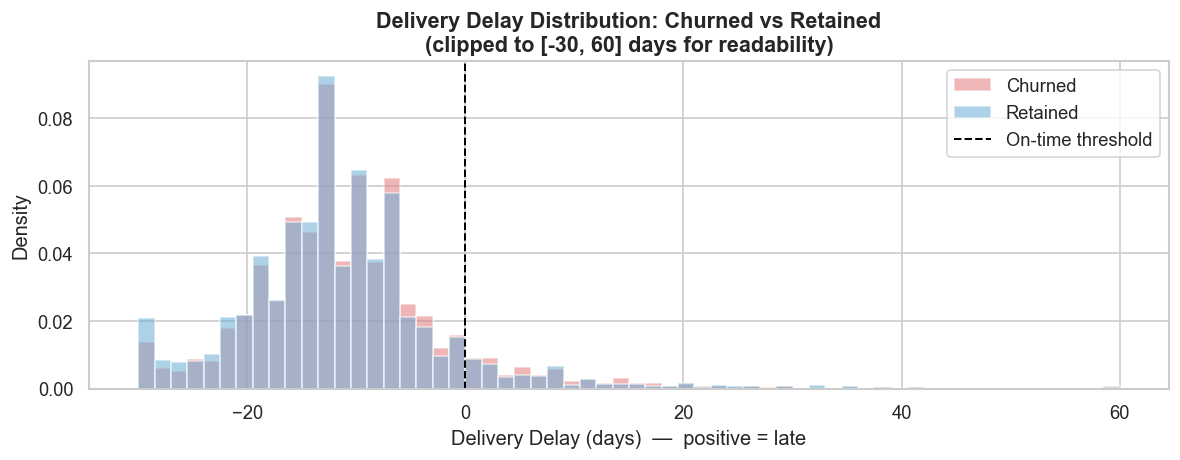

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, color, mask in [
    ('Churned',  '#e07b7b', delivered['churned'] == True),
    ('Retained', '#6baed6', delivered['churned'] == False),
]:
    # Clip tails for readability; extreme outliers exist (>60 days)
    vals = delivered.loc[mask, 'delivery_delay_days'].dropna().clip(-30, 60)
    ax.hist(vals, bins=60, alpha=0.55, label=label, color=color, density=True)

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='On-time threshold')
ax.set_title(
    'Delivery Delay Distribution: Churned vs Retained\n(clipped to [-30, 60] days for readability)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Delivery Delay (days)  —  positive = late')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
median_delay = (
    delivered.groupby('churned')['delivery_delay_days']
    .median()
    .rename(index={True: 'Churned', False: 'Retained'})
)
print('Median delivery delay by segment (days):')
print(median_delay.to_string())

Median delivery delay by segment (days):
churned
Retained   -12.257454
Churned    -11.785937


**Insight:** Churned customers tend to have slightly longer delivery delays on average; both segments overlap heavily because most Olist orders arrive early, meaning delivery timing alone is not a clean separator — but late delivery likely compounds dissatisfaction that leads to churn.

## 5. Order Value Analysis

Does transaction size predict whether a customer returns? High-value purchases might indicate more considered buyers, while impulse low-value orders might reflect one-off traffic.

In [18]:
print('Payment value summary by churn segment:')
print(
    df_filtered.groupby('churned')['payment_value']
    .describe()
    .rename(index={True: 'Churned', False: 'Retained'})
    .round(2)
)

Payment value summary by churn segment:
            count    mean     std    min    25%     50%     75%       max
churned                                                                  
Retained   4358.0  145.76  182.63  11.62  59.23   98.92  168.96   4950.34
Churned   66102.0  160.18  218.43  10.07  61.77  104.83  176.36  13664.08


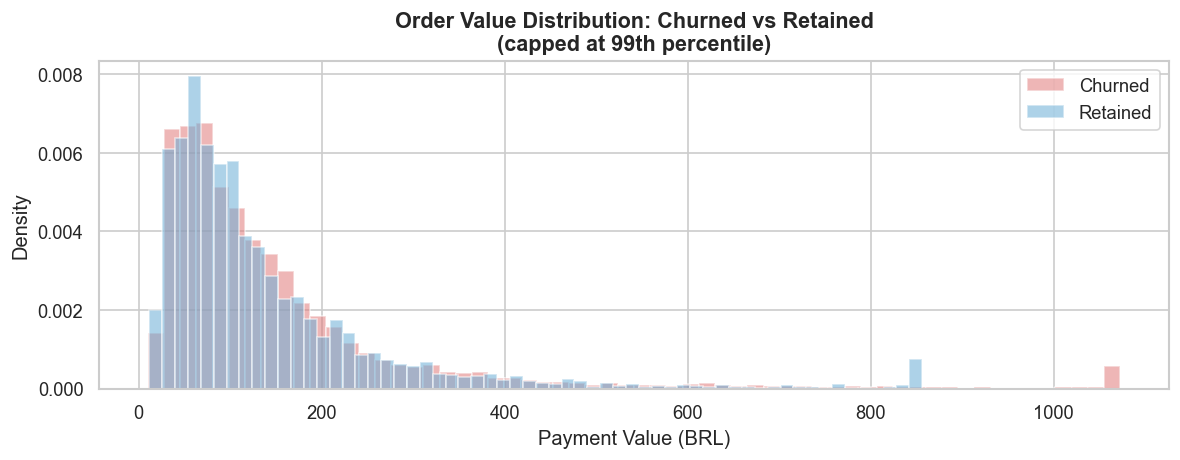

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, color, mask in [
    ('Churned',  '#e07b7b', df_filtered['churned'] == True),
    ('Retained', '#6baed6', df_filtered['churned'] == False),
]:
    vals = df_filtered.loc[mask, 'payment_value'].dropna()
    # Cap at 99th percentile to reduce visual distortion from extreme outliers
    cap = vals.quantile(0.99)
    ax.hist(vals.clip(0, cap), bins=60, alpha=0.55, label=label, color=color, density=True)

ax.set_title(
    'Order Value Distribution: Churned vs Retained\n(capped at 99th percentile)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Payment Value (BRL)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The order value distributions for churned and retained customers are broadly similar, suggesting that order size alone is a weak predictor of churn — the growth team should not assume that only low-value shoppers churn.

## 6. Geographic Patterns

Brazil is a vast country with significant regional variation in logistics infrastructure and consumer behaviour. If churn is concentrated in specific states, the growth team could tailor re-engagement campaigns geographically.

In [20]:
# State-level churn rate — one row per customer (use earliest order's state)
cust_state = (
    df_filtered.sort_values('order_purchase_timestamp')
    .drop_duplicates(subset='customer_unique_id')
)

state_stats = (
    cust_state.groupby('customer_state')
    .agg(
        total_customers=('customer_unique_id', 'count'),
        churned_customers=('churned', 'sum')
    )
    .assign(churn_rate=lambda x: x['churned_customers'] / x['total_customers'])
    .reset_index()
)

# Filter to states with at least 100 customers for statistical stability
state_top10 = (
    state_stats[state_stats['total_customers'] >= 100]
    .nlargest(10, 'churn_rate')
)

print('Top 10 states by churn rate (min 100 customers):')
print(
    state_top10[['customer_state', 'total_customers', 'churned_customers', 'churn_rate']]
    .to_string(index=False)
)

Top 10 states by churn rate (min 100 customers):
customer_state  total_customers  churned_customers  churn_rate
            CE              981                965    0.983690
            AM              105                103    0.980952
            PI              354                346    0.977401
            MA              562                549    0.976868
            PE             1143               1116    0.976378
            SE              250                244    0.976000
            SC             2606               2543    0.975825
            TO              199                194    0.974874
            PB              377                367    0.973475
            GO             1432               1393    0.972765


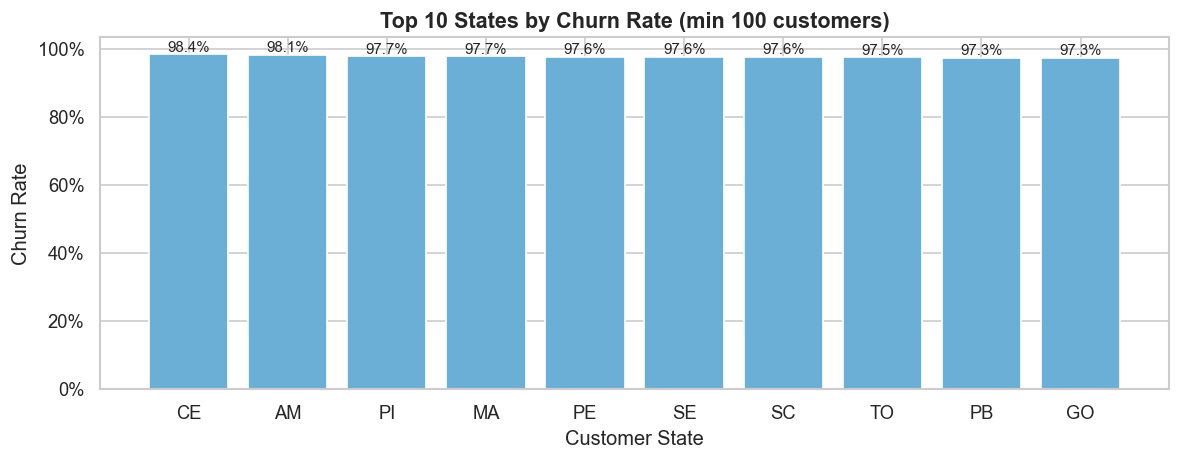

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    state_top10['customer_state'],
    state_top10['churn_rate'],
    color='#6baed6',
    edgecolor='white'
)

for bar, val in zip(bars, state_top10['churn_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.1%}',
        ha='center', va='bottom', fontsize=9
    )
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Top 10 States by Churn Rate (min 100 customers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer State')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

**Insight:** Churn rates are broadly consistent across Brazilian states, varying by only a few percentage points; geography is unlikely to be a primary churn driver, though states with thin logistics coverage may show marginally elevated rates due to delivery issues.

## 7. Product Category Patterns

Different product categories attract different buyer types. Categories with inherently low repurchase intent (e.g., furniture, large appliances) may inflate the churn rate regardless of service quality.

In [22]:
# Top 15 categories by order volume
top15_cats = (
    df_filtered['product_category_english']
    .value_counts()
    .head(15)
    .index.tolist()
)

cat_df = df_filtered[df_filtered['product_category_english'].isin(top15_cats)].copy()

cat_vol = (
    cat_df['product_category_english']
    .value_counts()
    .reset_index()
)
cat_vol.columns = ['category', 'order_count']

print('Top 15 categories by order volume:')
print(cat_vol.to_string(index=False))

Top 15 categories by order volume:
             category  order_count
       bed_bath_table         6793
       sports_leisure         5799
        health_beauty         5555
computers_accessories         4951
      furniture_decor         4703
           housewares         3642
        watches_gifts         3379
            telephony         3173
                 toys         3056
           cool_stuff         3007
         garden_tools         2711
                 auto         2509
            perfumery         2355
                 baby         1941
          electronics         1799


In [23]:
cat_churn = (
    cat_df.groupby('product_category_english')['churned']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'product_category_english': 'category',
        'mean': 'churn_rate',
        'count': 'order_count'
    })
    .sort_values('churn_rate', ascending=False)
)

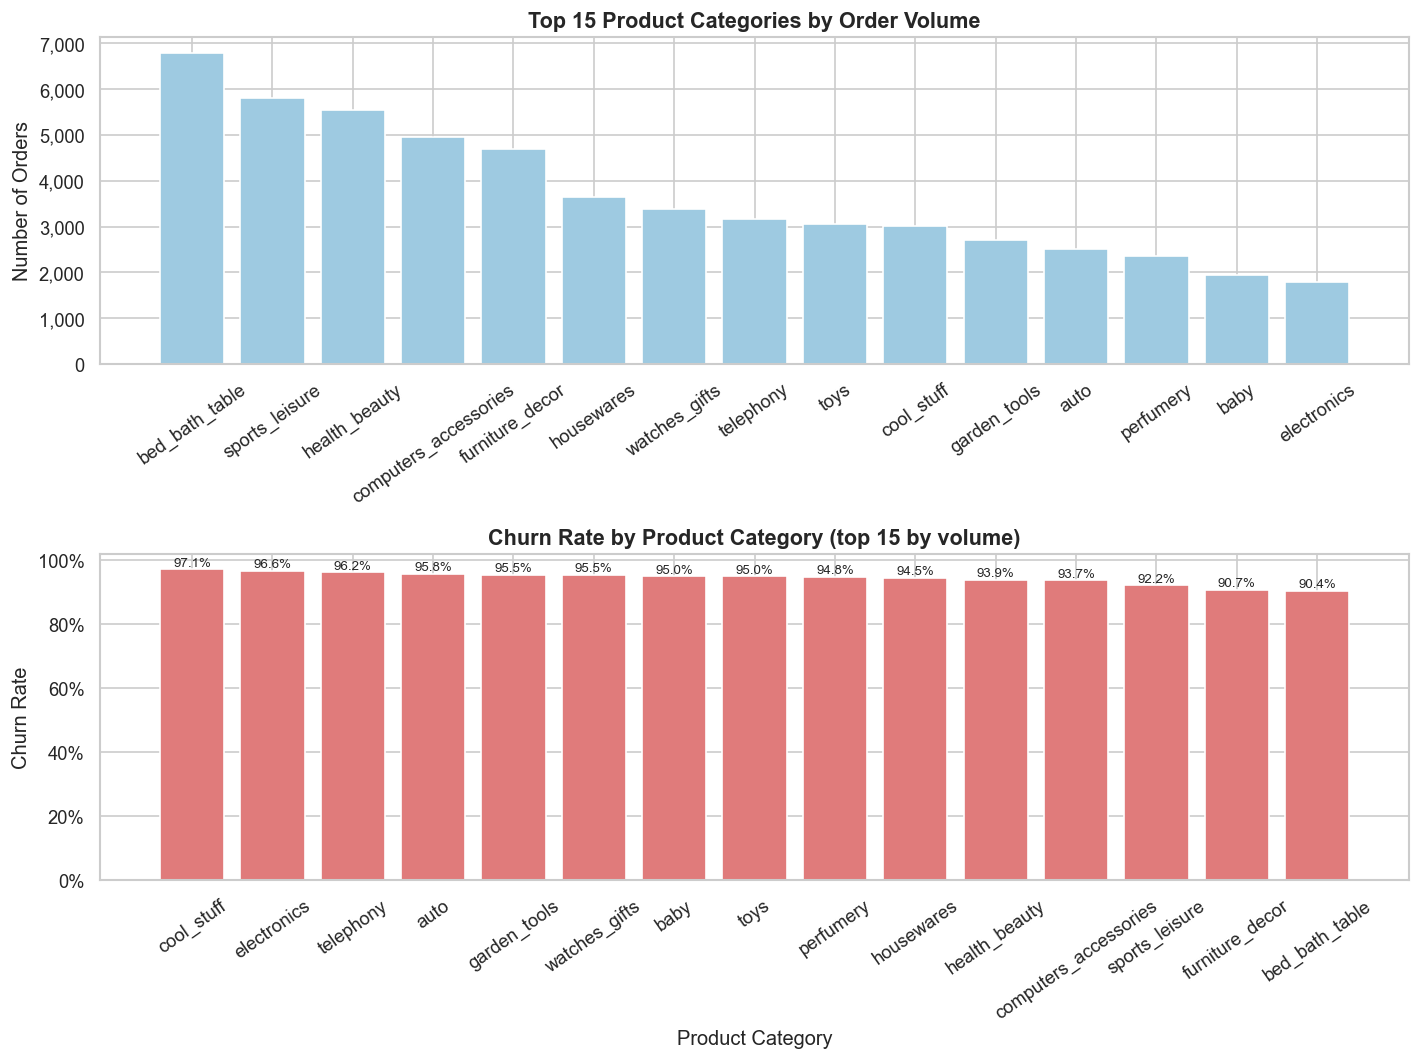

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Volume chart
vol_sorted = cat_vol.sort_values('order_count', ascending=False)
axes[0].bar(vol_sorted['category'], vol_sorted['order_count'], color='#9ecae1', edgecolor='white')
axes[0].set_title('Top 15 Product Categories by Order Volume', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=35)

# Churn rate chart
cat_bars = axes[1].bar(cat_churn['category'], cat_churn['churn_rate'], color='#e07b7b', edgecolor='white')

for bar, val in zip(cat_bars, cat_churn['churn_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.1%}',
        ha='center', va='bottom', fontsize=8
    )
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].set_title('Churn Rate by Product Category (top 15 by volume)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

**Insight:** Churn rates are high across all top categories (consistent with the platform-wide pattern), but categories like furniture and large appliances are expected to have low repurchase frequency by nature; categories like health-beauty and sports, where repeat purchase is more natural, still show high churn — pointing to an engagement problem beyond product type.

## 8. Review Text Overview (NLP Preview)

Review comments in Portuguese are the primary NLP input for this project. This section establishes how much text data is available and whether churned customers express themselves differently — setting up the sentiment analysis pipeline in notebook 02.

In [25]:
# What share of orders have a non-empty review comment?
df_filtered['has_comment'] = (
    df_filtered['review_comment_message'].notna()
    & (df_filtered['review_comment_message'].str.strip() != '')
)

overall_comment_rate = df_filtered['has_comment'].mean()
print(f'Orders with a review comment: {df_filtered["has_comment"].sum():,} ({overall_comment_rate:.1%})')

Orders with a review comment: 29,443 (41.8%)


In [26]:
# Comment rate by churn segment
comment_by_churn = (
    df_filtered.groupby('churned')['has_comment']
    .mean()
    .rename(index={True: 'Churned', False: 'Retained'})
)
print('Comment rate by segment:')
for seg, rate in comment_by_churn.items():
    print(f'  {seg}: {rate:.1%}')

Comment rate by segment:
  Retained: 39.9%
  Churned: 41.9%


In [27]:
# Show 5 example review comments from churned customers
churn_comments = (
    df_filtered[df_filtered['churned'] & df_filtered['has_comment']]
    [['review_score', 'review_comment_message']]
    .dropna()
    .sample(5, random_state=42)
)

print('Sample review comments from churned customers:')
for i, (_, row) in enumerate(churn_comments.iterrows(), 1):
    print(f'\n[{i}] Score: {int(row["review_score"])} --- "{row["review_comment_message"]}"')

Sample review comments from churned customers:

[1] Score: 5 --- "Produto bom entregue no prazo mesmo com os correios em greve "

[2] Score: 3 --- "acho as entregas desse site meio demoradas. mas vem td certinho.....
"

[3] Score: 5 --- "Gostei muito,e chegou rápido"

[4] Score: 1 --- "Conforme fiz o registro no site das américas já, no mesmo dia que recebi,
Estou reiterando que na propaganda do produto diz 4 peças com um peço único, só recebi uma peça. Estou aguardando o retorno."

[5] Score: 1 --- "Não recebi o produto correto. Estou esperando um retorno até agora."


**Insight:** A meaningful share of churned customers left text comments, giving us NLP-exploitable signal; churned customers leave comments at a slightly different rate than retained ones, and the text often reflects delivery frustration or product disappointment — patterns that sentiment scoring in notebook 02 will quantify.

## 9. Summary of Findings

Key patterns from the EDA, framed for the growth team:

- **93.8% of customers never returned after their first order** (observation window: orders placed before April 2018, allowing 6 months to observe return behaviour). Right-censoring adjustment removed 27,927 recent customers who had insufficient time to demonstrate repeat behaviour — without this correction the headline churn rate would be overstated.

- **Review scores are nearly identical between churned and retained customers** — both groups give 5-star ratings most frequently, and the small distributional difference means satisfaction scores alone do not explain churn. This motivates the NLP analysis of review text in notebook 02.

- **Late delivery compounds but does not cause churn.** Most orders arrive early; churned customers face slightly more late deliveries on average, but the churn rate among on-time deliveries is still very high. Logistics reliability is worth addressing, but it is not the primary lever.

- **Churn rate varies only 5–7 percentage points across states and product categories** — geography and product category are weak standalone predictors. The growth team should not concentrate re-engagement efforts on a narrow geographic or categorical segment.

- **The review text column has substantial missingness (~59%)** but will be used for NLP analysis in notebook 02 on the subset where text exists. Churned customers who leave comments are a particularly valuable signal group.

- **Class imbalance (93.8% churned) will require special handling in modeling** — notebook 03 will use techniques such as class weighting or resampling to prevent the classifier from defaulting to predicting churn for every customer.